# Student Performance Prediction

## Project Overview

This project builds a machine learning model to predict a student's **final score** from academic and student-related features.

The workflow followed in this notebook is:

**Understand the data → EDA → Clean the data → Prepare features → Train models → Evaluate models → Interpret the model → Check overfitting → Compare predictions**

The dataset is intentionally messy, so the first part of the project focuses on understanding and cleaning it before model training.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and Understanding the Dataset

In [2]:
df = pd.read_csv("student_performance_messy.csv")

In [3]:
df.shape

(2512, 13)

In [4]:
df.duplicated().sum()

np.int64(12)

In [5]:
df[df.duplicated()]

,student_id,gender,study_hours,attendance_percent,previous_score,assignments_completed,sleep_hours,internet_hours,extracurricular_activity,study_method,parent_education,internet_access,final_score
968,STU10433,Male,5.24,92.1,52.8,5,6.12,1.64,Clubs,Online Course,School,Yes,100.0
980,STU11969,Male,4.64,100.0,100.0,2,7.64,0.50,Sports,Self Study,College,Yes,100.0
1186,STU10171,Male,4.19,86.3,78.2,9,6.87,1.83,NaN,Coaching,College,Yes,100.0
1226,STU10922,Female,3.77,76.6,91.9,3,7.66,2.77,Volunteering,Self Study,College,Yes,100.0
1238,STU10998,Male,5.74,91.0,90.6,10,4.89,0.00,Clubs,Self Study,College,Yes,100.0
1348,STU11043,Male,6.90,76.2,49.2,9,8.36,3.09,NaN,Self Study,Postgraduate,Yes,100.0
1514,STU12226,Male,5.97,91.6,69.6,5,8.36,3.27,Sports,Online Course,College,Yes,100.0
1548,STU12451,Female,4.43,91.6,35.3,4,8.71,3.68,NaN,NaN,College,Yes,94.6
1794,STU12219,Male,4.20,81.4,66.8,6,7.05,3.87,NaN,Self Study,Postgraduate,Yes,96.3
1827,STU10064,Female,6.67,98.2,64.9,8,8.82,0.67,Music,Self Study,School,No,100.0


In [6]:
df.dtypes

student_id                   object
gender                       object
study_hours                 float64
attendance_percent           object
previous_score              float64
assignments_completed         int64
sleep_hours                 float64
internet_hours              float64
extracurricular_activity     object
study_method                 object
parent_education             object
internet_access              object
final_score                 float64
dtype: object

In [7]:
df.isnull().sum()

student_id                    0
gender                       61
study_hours                  87
attendance_percent           60
previous_score               76
assignments_completed         0
sleep_hours                 100
internet_hours               62
extracurricular_activity    943
study_method                 76
parent_education             62
internet_access              50
final_score                   8
dtype: int64

In [8]:
df.isnull().mean()*100

student_id                   0.000000
gender                       2.428344
study_hours                  3.463376
attendance_percent           2.388535
previous_score               3.025478
assignments_completed        0.000000
sleep_hours                  3.980892
internet_hours               2.468153
extracurricular_activity    37.539809
study_method                 3.025478
parent_education             2.468153
internet_access              1.990446
final_score                  0.318471
dtype: float64

In [9]:
df["attendance_percent"] = df["attendance_percent"].str.rstrip("%").astype(float)

# EDA

<Axes: xlabel='study_hours', ylabel='final_score'>

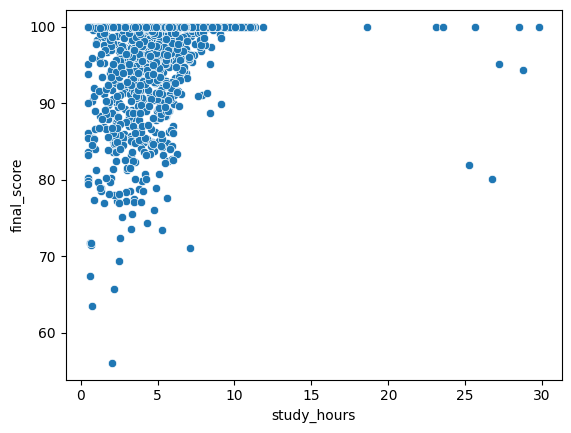

In [10]:
sns.scatterplot(data = df, x="study_hours", y="final_score")

<Axes: xlabel='internet_hours', ylabel='final_score'>

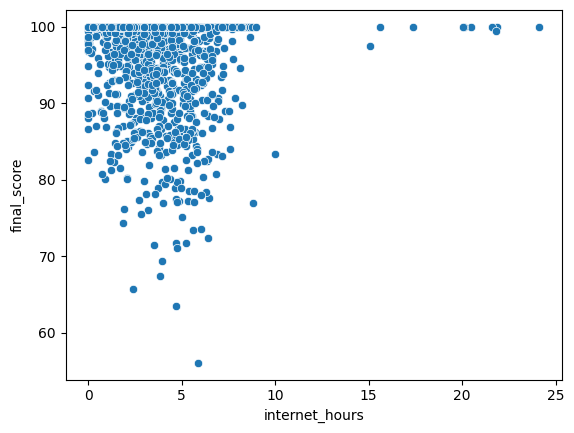

In [11]:
sns.scatterplot(data = df, x="internet_hours", y="final_score")

<Axes: xlabel='extracurricular_activity', ylabel='final_score'>

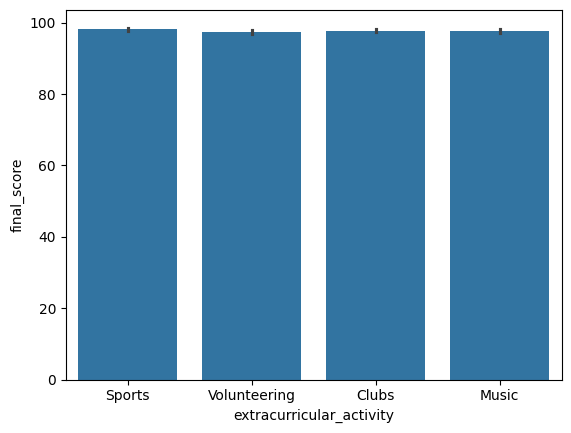

In [12]:
sns.barplot(data = df, x="extracurricular_activity", y="final_score")

<Axes: xlabel='study_method', ylabel='final_score'>

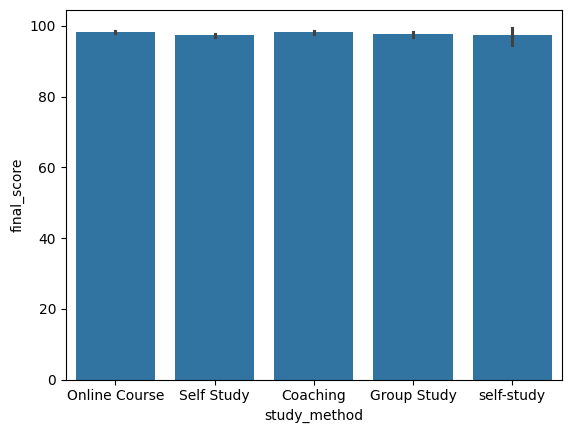

In [13]:
sns.barplot(data = df, x="study_method", y="final_score")

<Axes: >

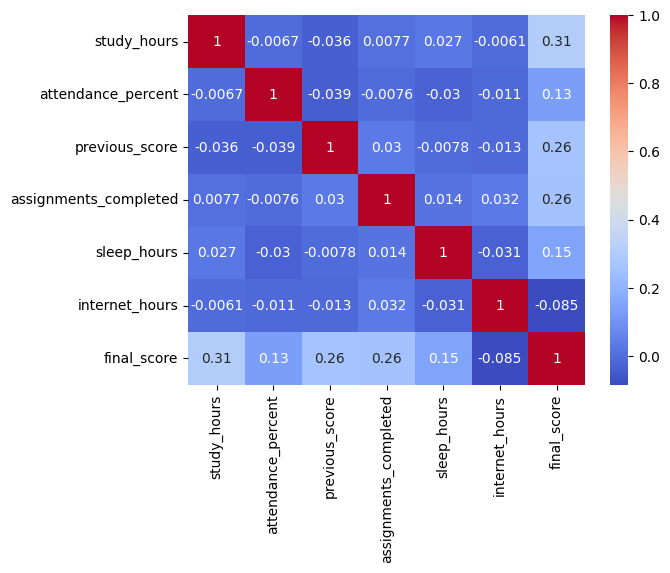

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

# Cleaning the Dataset

In [15]:
df.drop_duplicates()

,student_id,gender,study_hours,attendance_percent,previous_score,assignments_completed,sleep_hours,internet_hours,extracurricular_activity,study_method,parent_education,internet_access,final_score
0,STU12082,Male,6.27,87.6,82.5,5,7.19,NaN,NaN,Online Course,Postgraduate,No,100.0
1,STU10434,Female,1.84,90.7,82.3,7,8.33,2.19,NaN,Self Study,NaN,No,100.0
2,STU11725,NaN,7.75,69.7,74.4,8,7.32,2.12,NaN,Coaching,College,Yes,100.0
3,STU11252,Male,8.53,70.4,NaN,2,5.75,2.59,Sports,Coaching,College,Yes,100.0
4,STU10094,Male,5.34,86.6,68.0,4,7.50,1.26,Sports,Self Study,Postgraduate,Yes,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,STU11639,Female,5.52,65.9,78.5,4,7.05,6.93,NaN,Self Study,NaN,Yes,98.4
2508,STU11096,Male,7.95,100.0,82.2,10,7.11,4.67,NaN,Coaching,School,Yes,100.0
2509,STU11131,Male,3.71,86.7,66.0,9,6.08,4.40,NaN,Self Study,College,Yes,100.0
2510,STU11295,Other,6.02,60.3,52.0,3,6.99,1.50,Sports,Self Study,School,Yes,86.1


In [16]:
df["gender"].unique()

array(['Male', 'Female', nan, 'Other', 'male', ' FEMALE '], dtype=object)

In [17]:
df["gender"] = df["gender"].str.strip().str.capitalize()

In [18]:
df["gender"].unique()

array(['Male', 'Female', nan, 'Other'], dtype=object)

In [19]:
df.dropna(subset=["gender"], inplace=True)

In [20]:
df.shape

(2451, 13)

In [21]:
df.dropna(subset=["study_hours"], inplace=True)

In [22]:
for col in ["gender", "study_method", "parent_education", "internet_access"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
for col in ["study_hours", "attendance_percent", "previous_score", "sleep_hours", "internet_hours"]:
    df[col] = df[col].fillna(df[col].median())

In [24]:
df = df.drop(columns=["extracurricular_activity"])

In [25]:
df.dropna(subset=["final_score"], inplace=True)

# Model Training

In [26]:
df = pd.get_dummies(df, columns=["gender", "study_method", "parent_education", "internet_access"], drop_first=True)

In [27]:
X = df.drop(columns=["final_score", "student_id"])
y = df["final_score"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Linear Regression
MAE: 2.9780705395908567
RMSE: 4.620559244763034
R2: 0.30935685303197624

Random Forest
MAE: 2.2731881606765345
RMSE: 4.05228403321326
R2: 0.46879228083299385


In [32]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

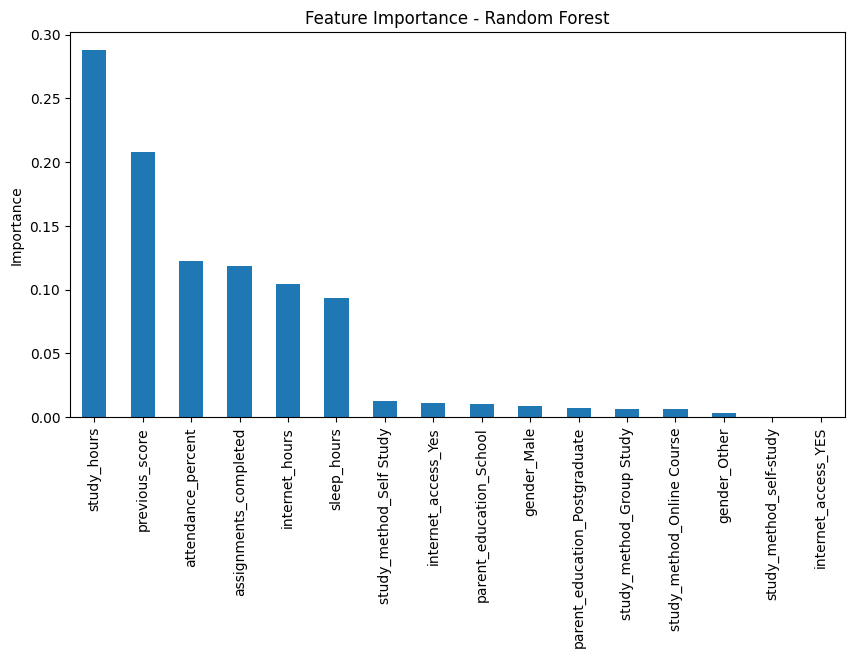

In [33]:
importance.plot(kind='bar', figsize=(10, 5))
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.show()

In [34]:
lr_train_pred = lr.predict(X_train)
rf_train_pred = rf.predict(X_train)

print("Linear Regression Train R²:",
      r2_score(y_train, lr_train_pred))

print("Linear Regression Test R²:",
      r2_score(y_test, lr_pred))

print("\nRandom Forest Train R²:",
      r2_score(y_train, rf_train_pred))

print("Random Forest Test R²:",
      r2_score(y_test, rf_pred))

Linear Regression Train R²: 0.2735780314157791
Linear Regression Test R²: 0.30935685303197624

Random Forest Train R²: 0.9202142575254728
Random Forest Test R²: 0.46879228083299385


In [35]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
rf_tuned_pred = rf_tuned.predict(X_test)

In [37]:
print("Train R²:", r2_score(y_train, rf_tuned.predict(X_train)))
print("Test R²:", r2_score(y_test, rf_tuned_pred))
print("MAE:", mean_absolute_error(y_test, rf_tuned_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_tuned_pred)))

Train R²: 0.8377596610394835
Test R²: 0.47884288635972183
MAE: 2.235717733922676
RMSE: 4.013765768973453


# Comparison

In [38]:
y_pred = rf_tuned.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,100.0,96.922533
1,100.0,99.915406
2,100.0,99.907866
3,81.6,93.784950
4,100.0,99.392210
5,97.9,88.996945
6,100.0,99.777623
7,100.0,99.985247
8,100.0,99.986479
9,100.0,99.964707


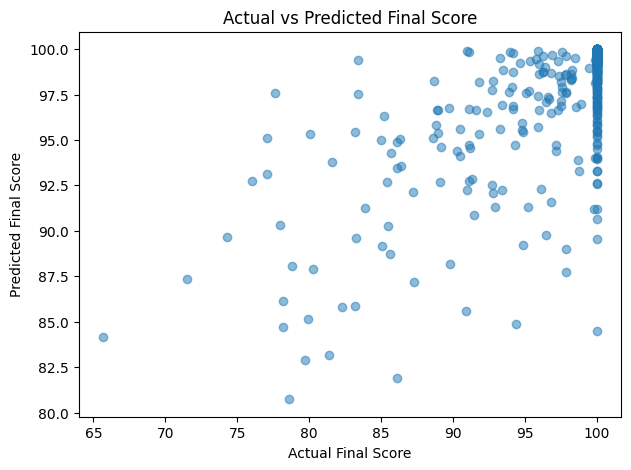

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.show()

# Final Model Check

In [40]:
print("Final Model: Tuned Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Final Model: Tuned Random Forest
MAE: 2.235717733922676
RMSE: 4.013765768973453
R²: 0.47884288635972183
